In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [6]:
from sqlalchemy.engine import URL

load_dotenv(".env")

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

print("DB_USER:", DB_USER)
print("DB_HOST:", DB_HOST)
print("DB_PORT:", DB_PORT)
print("DB_NAME:", DB_NAME)

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

engine = create_engine(connection_url)

DB_USER: postgres
DB_HOST: localhost
DB_PORT: 5432
DB_NAME: churn_project


In [8]:
query = """
SELECT *
FROM analytics_gold.gold_churn_model_input
"""

df = pd.read_sql(query, engine)

df.head()

,customer_id,churn,tenure,city_tier,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_from_last_year,coupon_used,order_count,day_since_last_order,cashback_amount,preferred_login_device,preferred_payment_mode,gender,preferred_order_cat,marital_status,tenure_missing_flag,warehouse_to_home_missing_flag,hour_spend_on_app_missing_flag,day_since_last_order_missing_flag,is_new_customer,low_satisfaction_flag,has_complaint,inactive_customer_flag,high_cashback_customer_flag,batch_id,loaded_at,loaded_by
0,50001,1,4.0,3,6.0,3.0,3.0,2,9.0,1,11.0,1.0,1.0,5.0,160.0,mobile phone,debit card,female,laptop & accessory,single,0,0,0,0,1,1,1,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
1,50002,1,0.0,1,8.0,3.0,4.0,3,7.0,1,15.0,0.0,1.0,0.0,121.0,phone,upi,male,mobile,single,1,0,0,0,1,0,1,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
2,50003,1,0.0,1,30.0,2.0,4.0,3,6.0,1,14.0,0.0,1.0,3.0,120.0,phone,debit card,male,mobile,single,1,0,0,0,1,0,1,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
3,50004,1,0.0,3,15.0,2.0,4.0,5,8.0,0,23.0,0.0,1.0,3.0,134.0,phone,debit card,male,laptop & accessory,single,0,0,0,0,1,0,0,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user
4,50005,1,0.0,1,12.0,0.0,3.0,5,3.0,0,11.0,1.0,1.0,3.0,130.0,phone,cc,male,mobile,single,0,0,1,0,1,0,0,0,0,f190cdea-1610-40b4-8591-813dff94068a,2026-06-17 14:50:23.631095,local_user


In [9]:
df.shape

(5630, 32)

In [10]:
df.columns.tolist()

['customer_id',
 'churn',
 'tenure',
 'city_tier',
 'warehouse_to_home',
 'hour_spend_on_app',
 'number_of_device_registered',
 'satisfaction_score',
 'number_of_address',
 'complain',
 'order_amount_hike_from_last_year',
 'coupon_used',
 'order_count',
 'day_since_last_order',
 'cashback_amount',
 'preferred_login_device',
 'preferred_payment_mode',
 'gender',
 'preferred_order_cat',
 'marital_status',
 'tenure_missing_flag',
 'warehouse_to_home_missing_flag',
 'hour_spend_on_app_missing_flag',
 'day_since_last_order_missing_flag',
 'is_new_customer',
 'low_satisfaction_flag',
 'has_complaint',
 'inactive_customer_flag',
 'high_cashback_customer_flag',
 'batch_id',
 'loaded_at',
 'loaded_by']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   customer_id                        5630 non-null   int64         
 1   churn                              5630 non-null   int64         
 2   tenure                             5630 non-null   float64       
 3   city_tier                          5630 non-null   int64         
 4   warehouse_to_home                  5630 non-null   float64       
 5   hour_spend_on_app                  5630 non-null   float64       
 6   number_of_device_registered        5630 non-null   float64       
 7   satisfaction_score                 5630 non-null   int64         
 8   number_of_address                  5630 non-null   float64       
 9   complain                           5630 non-null   int64         
 10  order_amount_hike_from_last_year   5

In [12]:
df.describe()

,customer_id,churn,tenure,city_tier,warehouse_to_home,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_from_last_year,coupon_used,order_count,day_since_last_order,cashback_amount,tenure_missing_flag,warehouse_to_home_missing_flag,hour_spend_on_app_missing_flag,day_since_last_order_missing_flag,is_new_customer,low_satisfaction_flag,has_complaint,inactive_customer_flag,high_cashback_customer_flag,loaded_at
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630
mean,52815.500000,0.168384,9.712078,1.654707,14.942629,2.798757,3.688988,3.066785,4.214032,0.284902,14.968561,1.671403,2.870160,4.295737,177.221492,0.046892,0.044583,0.045293,0.054529,0.428774,0.310835,0.284902,0.082593,0.238544,2026-06-17 14:50:23.631095296
min,50001.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-06-17 14:50:23.631095
25%,51408.250000,0.000000,1.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,1.000000,146.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-06-17 14:50:23.631095040
50%,52815.500000,0.000000,8.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,14.000000,1.000000,2.000000,3.000000,163.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2026-06-17 14:50:23.631095040
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,2026-06-17 14:50:23.631095040
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2026-06-17 14:50:23.631095
std,1625.385339,0.374240,8.627486,0.915389,8.942111,0.932334,1.023999,1.380194,2.583586,0.451408,4.893091,1.886648,2.939615,3.700134,49.193869,0.211426,0.206404,0.207965,0.227079,0.494945,0.462876,0.451408,0.275291,0.426231,NaN


In [13]:
df["churn"].value_counts()

churn
0    4682
1     948
Name: count, dtype: int64

In [14]:
df["churn"].value_counts(normalize=True) * 100

churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

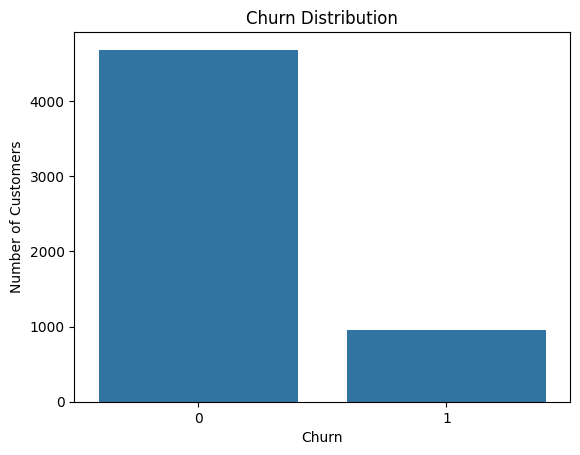

In [15]:
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [16]:
df.isna().sum().sort_values(ascending=False)

customer_id                          0
churn                                0
tenure                               0
city_tier                            0
warehouse_to_home                    0
hour_spend_on_app                    0
number_of_device_registered          0
satisfaction_score                   0
number_of_address                    0
complain                             0
order_amount_hike_from_last_year     0
coupon_used                          0
order_count                          0
day_since_last_order                 0
cashback_amount                      0
preferred_login_device               0
preferred_payment_mode               0
gender                               0
preferred_order_cat                  0
marital_status                       0
tenure_missing_flag                  0
warehouse_to_home_missing_flag       0
hour_spend_on_app_missing_flag       0
day_since_last_order_missing_flag    0
is_new_customer                      0
low_satisfaction_flag    

In [17]:
missing_percent = df.isna().mean().sort_values(ascending=False) * 100
missing_percent

customer_id                          0.0
churn                                0.0
tenure                               0.0
city_tier                            0.0
warehouse_to_home                    0.0
hour_spend_on_app                    0.0
number_of_device_registered          0.0
satisfaction_score                   0.0
number_of_address                    0.0
complain                             0.0
order_amount_hike_from_last_year     0.0
coupon_used                          0.0
order_count                          0.0
day_since_last_order                 0.0
cashback_amount                      0.0
preferred_login_device               0.0
preferred_payment_mode               0.0
gender                               0.0
preferred_order_cat                  0.0
marital_status                       0.0
tenure_missing_flag                  0.0
warehouse_to_home_missing_flag       0.0
hour_spend_on_app_missing_flag       0.0
day_since_last_order_missing_flag    0.0
is_new_customer 

In [18]:
df["customer_id"].duplicated().sum()

np.int64(0)

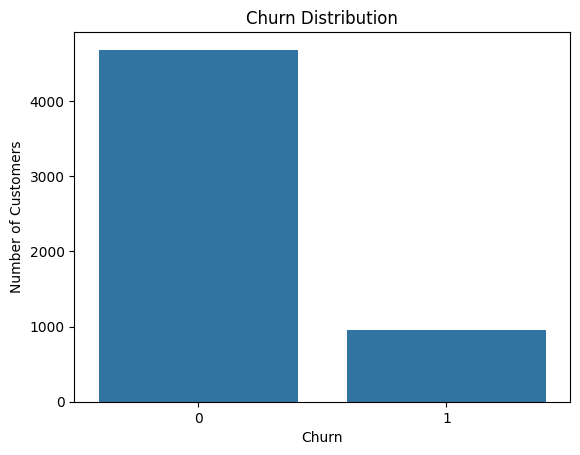

In [ ]:
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


### Insight 1: Overall churn rate

The dataset contains 5,630 customers. Around 16.84% of customers churned, while 83.16% did not churn. This means the dataset is imbalanced, so accuracy alone may not be enough to evaluate the model later.

In [21]:
complain_churn = pd.crosstab(
    df["complain"],
    df["churn"],
    normalize="index"
) * 100

complain_churn

churn,0,1
complain,,
0,89.071038,10.928962
1,68.329177,31.670823


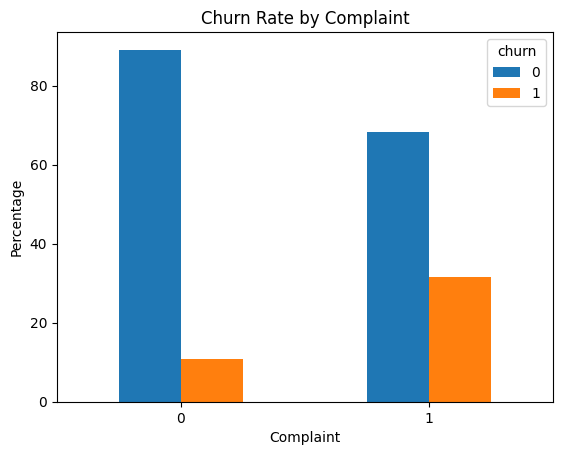

In [22]:
complain_churn.plot(kind="bar")
plt.title("Churn Rate by Complaint")
plt.xlabel("Complaint")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [23]:
satisfaction_churn = pd.crosstab(
    df["satisfaction_score"],
    df["churn"],
    normalize="index"
) * 100

satisfaction_churn

churn,0,1
satisfaction_score,,
1,88.487973,11.512027
2,87.372014,12.627986
3,82.803298,17.196702
4,82.867784,17.132216
5,76.173285,23.826715


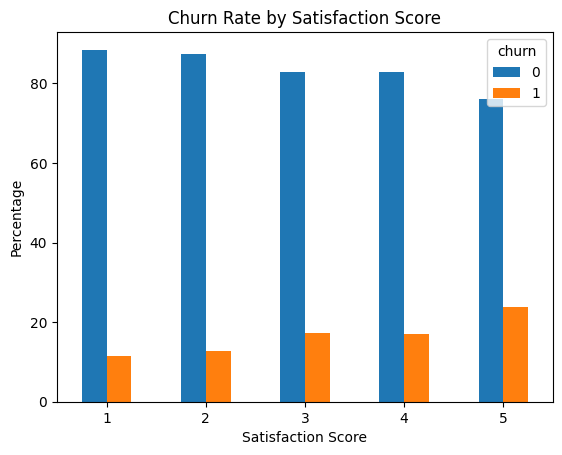

In [24]:
satisfaction_churn.plot(kind="bar")
plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

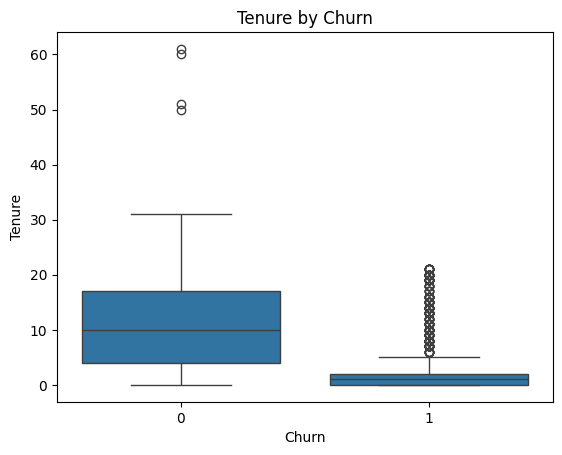

In [25]:
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

In [26]:
df.groupby("churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,4682.0,11.052755,8.548815,0.0,4.0,10.0,17.0,61.0
1,948.0,3.090717,5.330690,0.0,0.0,1.0,2.0,21.0


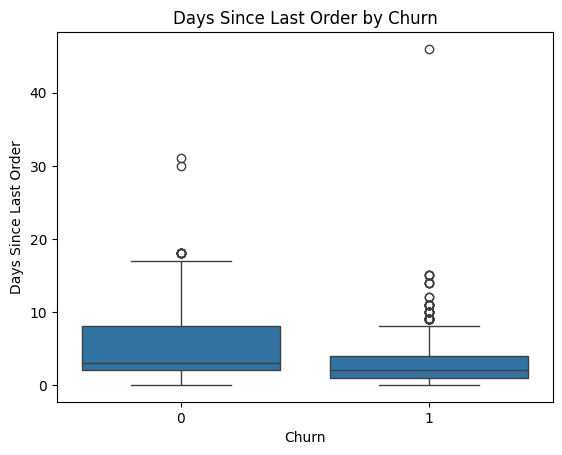

In [27]:
sns.boxplot(data=df, x="churn", y="day_since_last_order")
plt.title("Days Since Last Order by Churn")
plt.xlabel("Churn")
plt.ylabel("Days Since Last Order")
plt.show()

In [28]:
df.groupby("churn")["day_since_last_order"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,4682.0,4.547629,3.707815,0.0,2.0,3.0,8.0,31.0
1,948.0,3.051688,3.400178,0.0,1.0,2.0,4.0,46.0


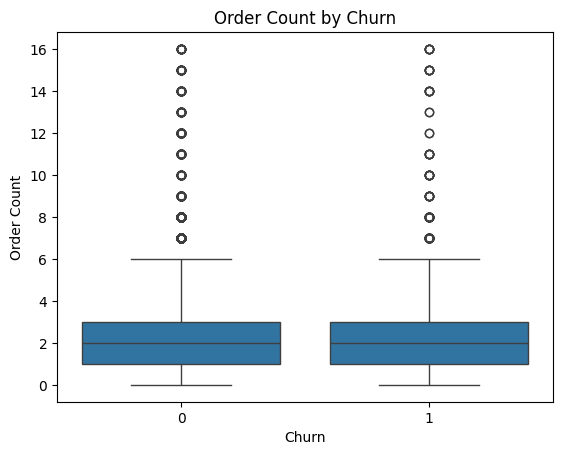

In [29]:
sns.boxplot(data=df, x="churn", y="order_count")
plt.title("Order Count by Churn")
plt.xlabel("Churn")
plt.ylabel("Order Count")
plt.show()

In [30]:
df.groupby("churn")["order_count"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,4682.0,2.890431,2.965110,0.0,1.0,2.0,3.0,16.0
1,948.0,2.770042,2.809674,0.0,1.0,2.0,3.0,16.0


In [31]:
order_cat_churn = pd.crosstab(
    df["preferred_order_cat"],
    df["churn"],
    normalize="index"
) * 100

order_cat_churn.sort_values(by=1, ascending=False)

churn,0,1
preferred_order_cat,,
mobile phone,72.462628,27.537372
mobile,72.805933,27.194067
fashion,84.503632,15.496368
laptop & accessory,89.756098,10.243902
others,92.424242,7.575758
grocery,95.121951,4.878049


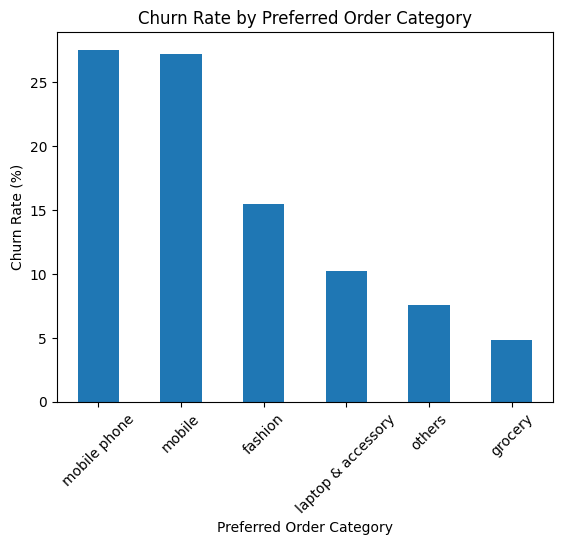

In [32]:
order_cat_churn[1].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Preferred Order Category")
plt.xlabel("Preferred Order Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [33]:
payment_churn = pd.crosstab(
    df["preferred_payment_mode"],
    df["churn"],
    normalize="index"
) * 100

payment_churn.sort_values(by=1, ascending=False)

churn,0,1
preferred_payment_mode,,
cod,71.232877,28.767123
e wallet,77.198697,22.801303
cc,78.388278,21.611722
upi,82.608696,17.391304
cash on delivery,84.563758,15.436242
debit card,84.615385,15.384615
credit card,87.141905,12.858095


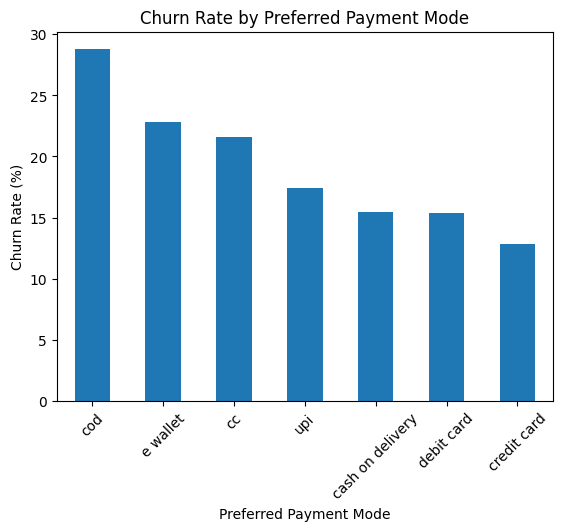

In [34]:
payment_churn[1].sort_values(ascending=False).plot(kind="bar")
plt.title("Churn Rate by Preferred Payment Mode")
plt.xlabel("Preferred Payment Mode")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Initial EDA Insights

The dataset contains 5,630 customers and 32 columns. The overall churn rate is around 16.84%, which means the dataset is moderately imbalanced.

Customers with complaints show a much higher churn rate. Customers without complaints have a churn rate of around 10.93%, while customers with complaints have a churn rate of around 31.67%. This suggests that complaint handling may be an important factor in customer retention.

Tenure appears to be one of the strongest churn-related variables. Non-churned customers have an average tenure of around 11.05, while churned customers have an average tenure of only around 3.09. This suggests that newer customers are more likely to churn, so early-stage onboarding and engagement may be important.

Satisfaction score does not show a simple pattern. Surprisingly, customers with satisfaction score 5 have the highest churn rate. This needs further investigation before making a business conclusion.

Days since last order and order count do not show a strong difference between churned and non-churned customers in this initial analysis.

Preferred order category shows a clear pattern. Customers whose preferred category is mobile phone or mobile have the highest churn rates, while grocery customers have the lowest churn rate. This may suggest that some categories are more one-off purchase driven, while others are more repeat-driven.

Preferred payment mode also shows differences in churn rate. However, some values may represent the same meaning, such as "cod" and "cash on delivery", or "cc" and "credit card". These categories should be standardized before machine learning.

In [35]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


preferred_login_device
preferred_login_device
mobile phone    2765
computer        1634
phone           1231
Name: count, dtype: int64

preferred_payment_mode
preferred_payment_mode
debit card          2314
credit card         1501
e wallet             614
upi                  414
cod                  365
cc                   273
cash on delivery     149
Name: count, dtype: int64

gender
gender
male      3384
female    2246
Name: count, dtype: int64

preferred_order_cat
preferred_order_cat
laptop & accessory    2050
mobile phone          1271
fashion                826
mobile                 809
grocery                410
others                 264
Name: count, dtype: int64

marital_status
marital_status
married     2986
single      1796
divorced     848
Name: count, dtype: int64

batch_id
batch_id
f190cdea-1610-40b4-8591-813dff94068a    5630
Name: count, dtype: int64

loaded_by
loaded_by
local_user    5630
Name: count, dtype: int64


In [36]:
flag_cols = [
    "is_new_customer",
    "low_satisfaction_flag",
    "has_complaint",
    "inactive_customer_flag",
    "high_cashback_customer_flag"
]

for col in flag_cols:
    print(f"\nChurn rate by {col}")
    print(pd.crosstab(df[col], df["churn"], normalize="index") * 100)


Churn rate by is_new_customer
churn                    0          1
is_new_customer                      
0                94.713930   5.286070
1                67.771334  32.228666

Churn rate by low_satisfaction_flag
churn                          0          1
low_satisfaction_flag                      
0                      80.927835  19.072165
1                      88.114286  11.885714

Churn rate by has_complaint
churn                  0          1
has_complaint                      
0              89.071038  10.928962
1              68.329177  31.670823

Churn rate by inactive_customer_flag
churn                           0          1
inactive_customer_flag                      
0                       82.207164  17.792836
1                       93.763441   6.236559

Churn rate by high_cashback_customer_flag
churn                                0          1
high_cashback_customer_flag                      
0                            81.152321  18.847679
1                   

In [37]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr_with_churn = df[numeric_cols].corr()["churn"].sort_values(ascending=False)
corr_with_churn

churn                                1.000000
is_new_customer                      0.356325
complain                             0.250188
has_complaint                        0.250188
number_of_device_registered          0.107939
satisfaction_score                   0.105481
warehouse_to_home_missing_flag       0.095986
city_tier                            0.084703
tenure_missing_flag                  0.082056
number_of_address                    0.043931
order_amount_hike_from_last_year     0.039369
hour_spend_on_app_missing_flag       0.034381
warehouse_to_home                    0.033889
coupon_used                          0.007425
day_since_last_order_missing_flag    0.004821
hour_spend_on_app                   -0.008768
order_count                         -0.015327
customer_id                         -0.019083
inactive_customer_flag              -0.085008
low_satisfaction_flag               -0.088885
high_cashback_customer_flag         -0.095935
day_since_last_order              

## Additional EDA Findings

The EDA shows that `is_new_customer`, `tenure`, and `complain` are among the most important churn-related variables.

New customers have a much higher churn rate than existing customers. Customers flagged as new have a churn rate of around 32.23%, while non-new customers have a churn rate of around 5.29%. This suggests that early customer onboarding and engagement are critical for retention.

Customers with complaints are also much more likely to churn. Customers without complaints have a churn rate of around 10.93%, while customers with complaints have a churn rate of around 31.67%. This suggests that complaint handling may be an important retention strategy.

Tenure has a negative correlation with churn. This means that customers with longer tenure are less likely to churn. This is consistent with the earlier descriptive statistics, where churned customers had much lower average tenure than non-churned customers.

Some variables do not behave as expected. For example, satisfaction score has a slightly positive correlation with churn, and customers with the highest satisfaction score showed the highest churn rate. Similarly, inactive customer flag does not show the expected relationship with churn. These variables need further investigation before making strong business conclusions.

The EDA also shows that some categorical values should be standardized before machine learning. For example, `cod` and `cash on delivery` may represent the same payment method, while `cc` and `credit card` may also represent the same category.

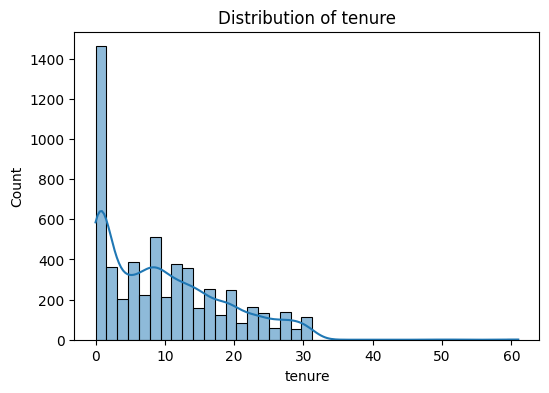

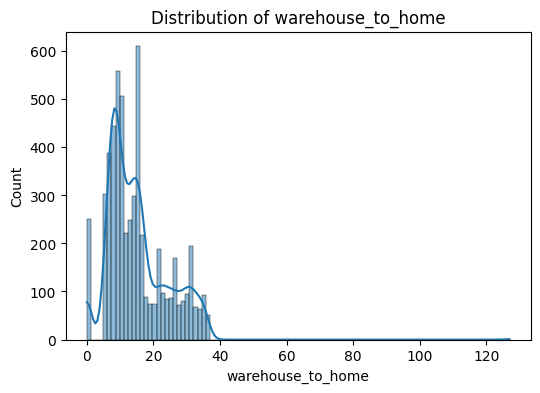

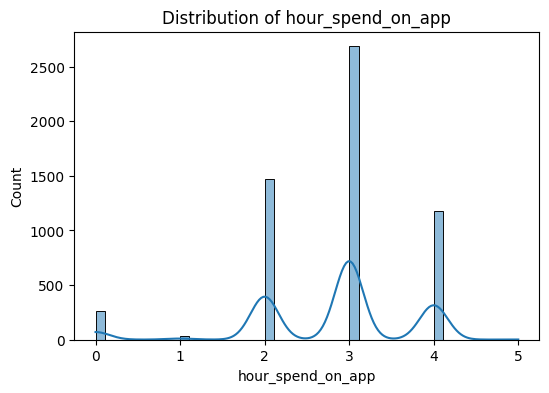

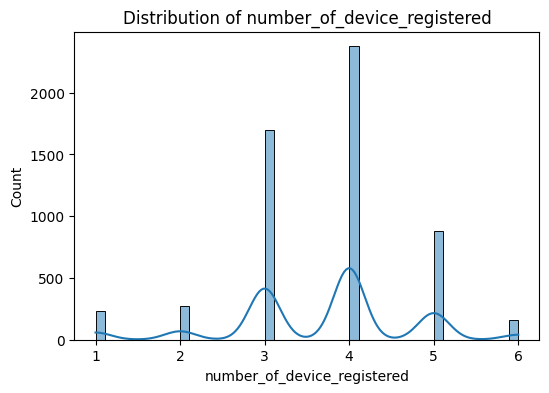

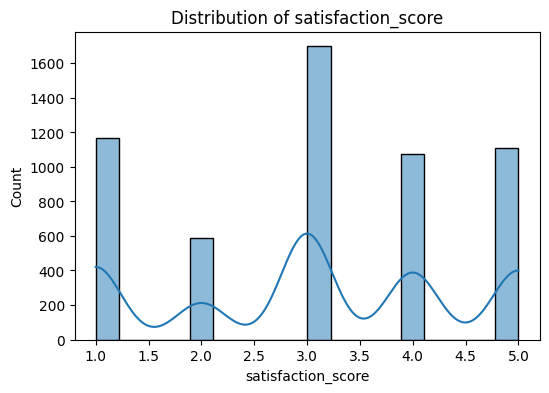

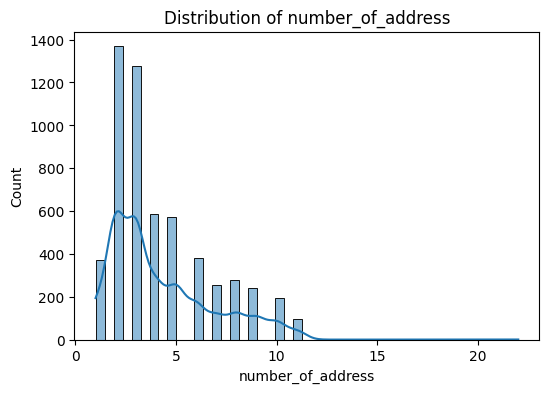

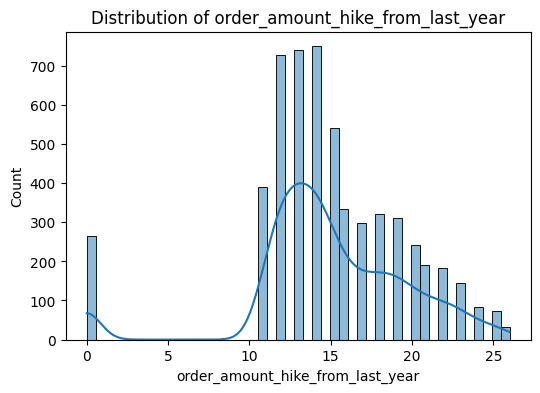

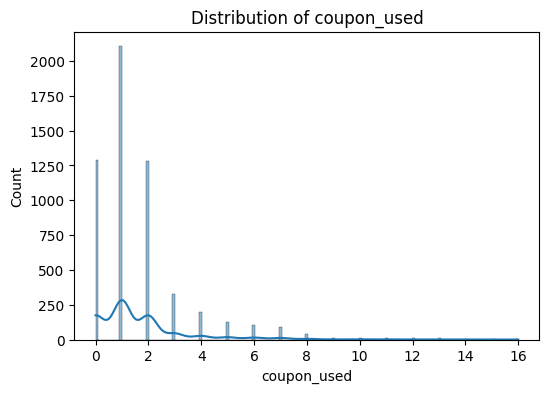

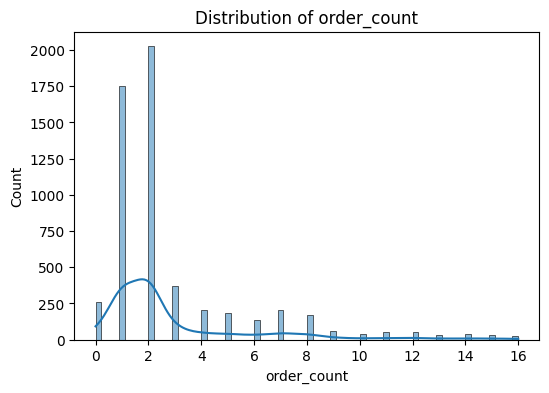

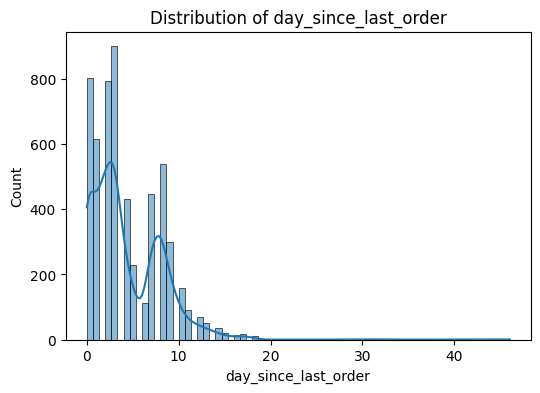

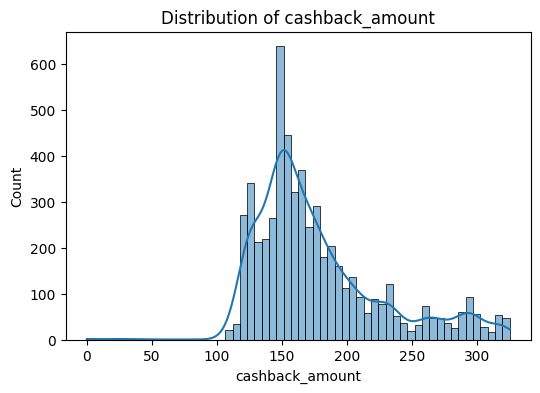

In [38]:
numeric_cols = [
    "tenure",
    "warehouse_to_home",
    "hour_spend_on_app",
    "number_of_device_registered",
    "satisfaction_score",
    "number_of_address",
    "order_amount_hike_from_last_year",
    "coupon_used",
    "order_count",
    "day_since_last_order",
    "cashback_amount"
]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Numeric Feature Distribution

Most numeric variables are not normally distributed. Several variables such as tenure, warehouse_to_home, number_of_address, coupon_used, order_count, and day_since_last_order are right-skewed. This means most customers have relatively low values, while a smaller group of customers have much higher values.

Some variables are discrete rather than continuous, such as hour_spend_on_app, number_of_device_registered, satisfaction_score, coupon_used, and order_count.

The distributions suggest that outliers should be checked carefully. However, because this is customer behavior data, extreme values may represent real customer behavior rather than data errors. Therefore, outliers should not be removed automatically.

In [39]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percent = outlier_count / len(df) * 100
    
    outlier_summary.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_percent
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values("outlier_percent", ascending=False)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
8,order_count,1.0,3.0,2.0,-2.0,6.0,703,12.486679
7,coupon_used,1.0,2.0,1.0,-0.5,3.5,629,11.172291
10,cashback_amount,146.0,196.0,50.0,71.0,271.0,447,7.939609
3,number_of_device_registered,3.0,4.0,1.0,1.5,5.5,397,7.051510
6,order_amount_hike_from_last_year,13.0,18.0,5.0,5.5,25.5,298,5.293073
2,hour_spend_on_app,2.0,3.0,1.0,0.5,4.5,261,4.635879
9,day_since_last_order,1.0,7.0,6.0,-8.0,16.0,30,0.532860
5,number_of_address,2.0,6.0,4.0,-4.0,12.0,4,0.071048
0,tenure,1.0,15.0,14.0,-20.0,36.0,4,0.071048
1,warehouse_to_home,9.0,20.0,11.0,-7.5,36.5,2,0.035524


## Outlier Analysis

Outliers were checked using the IQR method. The variables with the highest outlier percentages are `order_count`, `coupon_used`, `cashback_amount`, `number_of_device_registered`, `order_amount_hike_from_last_year`, and `hour_spend_on_app`.

However, these outliers may represent real customer behavior rather than data errors. For example, some customers may place more orders, use more coupons, receive higher cashback, or register more devices.

Therefore, outliers will not be removed during the EDA stage. In the machine learning stage, different approaches can be compared, such as keeping outliers, capping extreme values, or using tree-based models that are less sensitive to outliers.

## EDA Conclusion

The exploratory data analysis shows that the Gold table is clean and ready for machine learning.

The dataset contains 5,630 customers and 32 columns. There are no missing values and no duplicated customer IDs. The overall churn rate is around 16.84%, while around 83.16% of customers did not churn. This means the dataset is moderately imbalanced, so accuracy alone should not be the only metric used during model evaluation.

Several variables appear to be strongly related to churn. Customers with complaints have a much higher churn rate than customers without complaints. New customers and customers with lower tenure are also more likely to churn. Tenure is one of the clearest churn-related variables, as churned customers tend to have much shorter tenure than non-churned customers.

Preferred order category also shows meaningful differences. Customers whose preferred categories are mobile phone and mobile have higher churn rates, while grocery customers have the lowest churn rate. This may suggest that some product categories are more one-time purchase driven, while others are more repeat-purchase driven.

Some variables show unexpected patterns and should be interpreted carefully. For example, satisfaction score does not show a simple negative relationship with churn. Customers with higher satisfaction scores still show relatively high churn in this dataset. Similarly, day_since_last_order and inactive_customer_flag do not behave exactly as expected.

Outliers were detected in several behavioral variables such as order_count, coupon_used, cashback_amount, and number_of_device_registered. However, these outliers were not removed during EDA because they may represent real customer behavior rather than data errors.

Overall, the EDA suggests that customer churn is mainly associated with early customer lifecycle, complaint behavior, tenure, product category, and engagement-related variables. The next step is to use the cleaned Gold table for supervised machine learning.